In [146]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [147]:
df = pd.read_csv("../data/customer_segmentation.csv")
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [148]:
print(f"The data has {df.shape[0]} rows and {df.shape[1]} columns")

The data has 2240 rows and 29 columns


In [149]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='str')

In [150]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   str    
 3   Marital_Status       2240 non-null   str    
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   str    
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   int64  
 16 

In [151]:
df.duplicated().sum()

np.int64(0)

In [152]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [153]:
# Filling missing values with median (Robust to outliers)
df["Income"] = df["Income"].fillna(df["Income"].median())

In [154]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,2240.0,5592.159821,3246.662198,0.0,2828.25,5458.5,8427.75,11191.0
Year_Birth,2240.0,1968.805804,11.984069,1893.0,1959.00,1970.0,1977.00,1996.0
Income,2240.0,52237.975446,25037.955891,1730.0,35538.75,51381.5,68289.75,666666.0
Kidhome,2240.0,0.444196,0.538398,0.0,0.00,0.0,1.00,2.0
Teenhome,2240.0,0.506250,0.544538,0.0,0.00,0.0,1.00,2.0
Recency,2240.0,49.109375,28.962453,0.0,24.00,49.0,74.00,99.0
MntWines,2240.0,303.935714,336.597393,0.0,23.75,173.5,504.25,1493.0
MntFruits,2240.0,26.302232,39.773434,0.0,1.00,8.0,33.00,199.0
MntMeatProducts,2240.0,166.950000,225.715373,0.0,16.00,67.0,232.00,1725.0
MntFishProducts,2240.0,37.525446,54.628979,0.0,3.00,12.0,50.00,259.0


# Feature Engineering

In [155]:
# Changed Dt_Customer datatype to datetime
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst=True)

In [156]:
# Create New Age Column
df["Age"] = 2026 - df["Year_Birth"]

In [157]:
# Created new Total_Children Column
df["Total_Children"] = df["Kidhome"] + df["Teenhome"]

In [158]:
# Created new Total_Spending Column
spending_columns = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
df["Total_Spending"] = df[spending_columns].sum(axis=1)

In [159]:
# Created new Customer_Since Column
df["Customer_Since"] = (pd.Timestamp("today") - df["Dt_Customer"]).dt.days

In [160]:
df["Customer_Since"]

0       5041
1       4491
2       4690
3       4517
4       4539
        ... 
2235    4759
2236    4397
2237    4533
2238    4534
2239    5000
Name: Customer_Since, Length: 2240, dtype: int64

In [161]:
# Numerical and Categorical Columns
numerical_columns = df.select_dtypes(include=['number']).columns.to_list()
categorical_columns = df.select_dtypes(include=['string']).columns.to_list()

print(f'We have {len(numerical_columns)} numerical columns: {numerical_columns}')
print(f'We have {len(categorical_columns)} categorical columns: {categorical_columns}')

We have 30 numerical columns: ['ID', 'Year_Birth', 'Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response', 'Age', 'Total_Children', 'Total_Spending', 'Customer_Since']
We have 2 categorical columns: ['Education', 'Marital_Status']


# Univariate Analysis of categorical variables

<Axes: xlabel='Education', ylabel='count'>

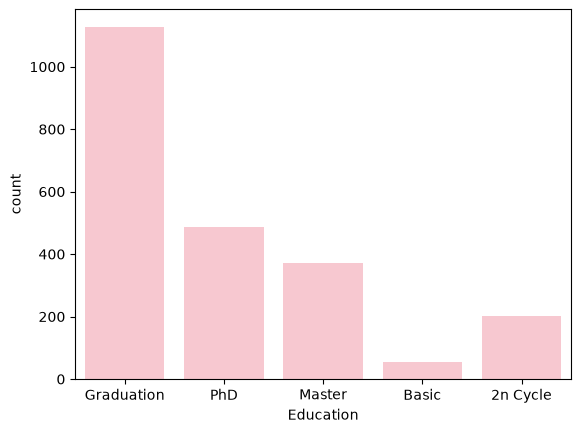

In [162]:
sns.countplot(data=df, x=df["Education"], color="pink")

<Axes: xlabel='Marital_Status', ylabel='count'>

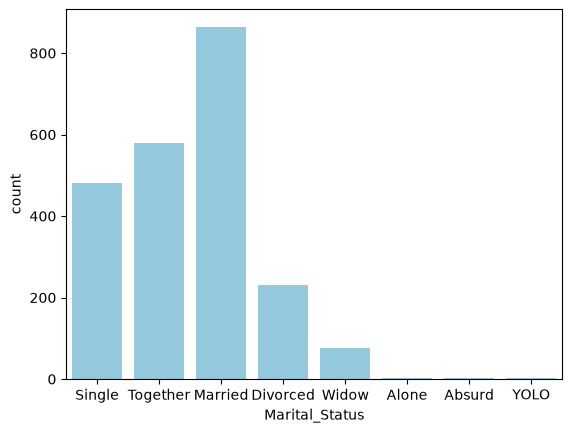

In [163]:
sns.countplot(data=df, x=df["Marital_Status"], color="skyblue")

# Univariate Analysis of numerical variables

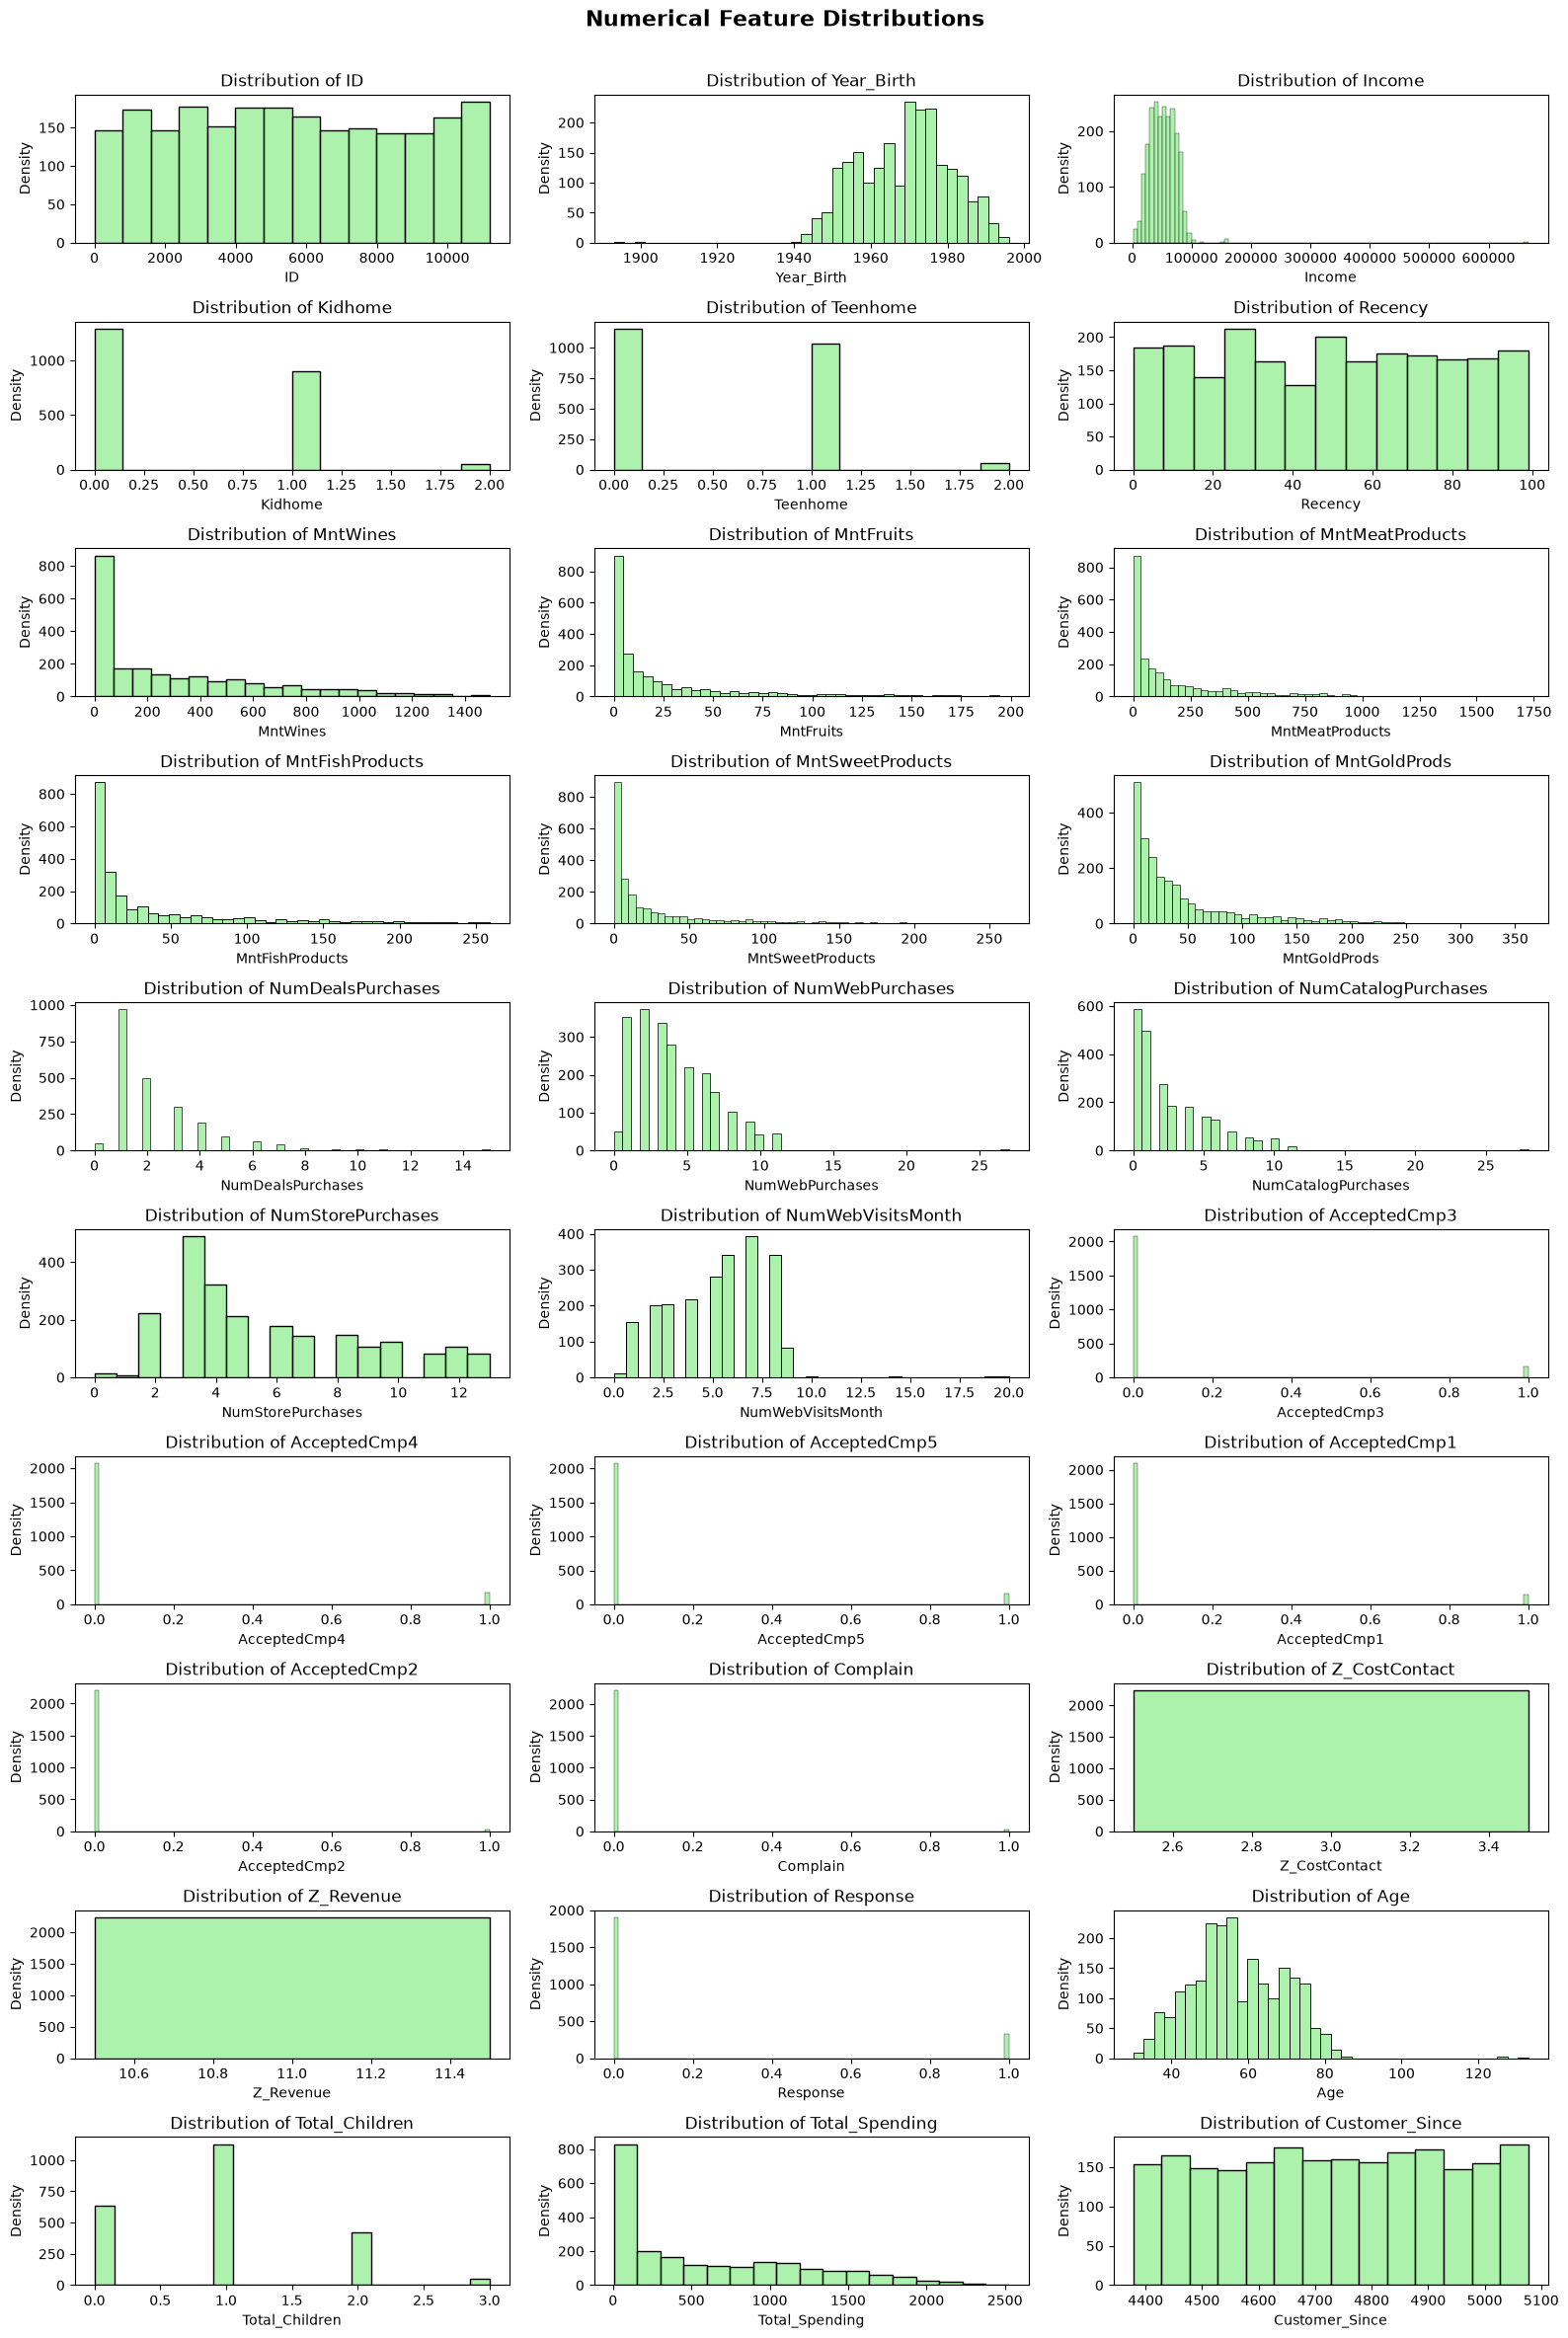

In [164]:
plt.figure(figsize=(16, 25))
for i, feature in enumerate(numerical_columns, 1):
    plt.subplot(11, 3, i)
    sns.histplot(data=df, x=feature, color="lightgreen")
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Density')

plt.tight_layout()
plt.suptitle("Numerical Feature Distributions", fontsize=16, y=1.02, fontweight='bold')
plt.show()

Text(0.5, 1.0, 'Age Distribution')

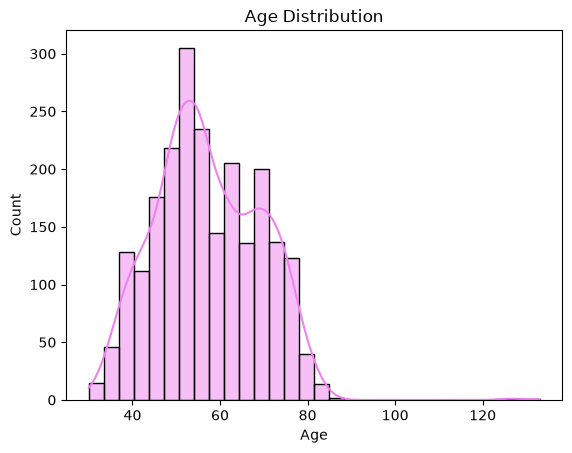

In [165]:
sns.histplot(df["Age"], bins=30, kde=True, color="violet")
plt.title("Age Distribution")

Text(0.5, 1.0, 'Income Distribution')

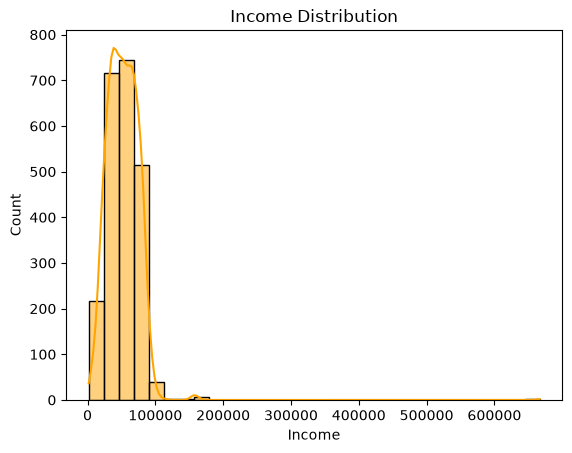

In [166]:
sns.histplot(df["Income"], bins=30, kde=True, color="orange")
plt.title("Income Distribution")

Text(0.5, 1.0, 'Total Spending Distribution')

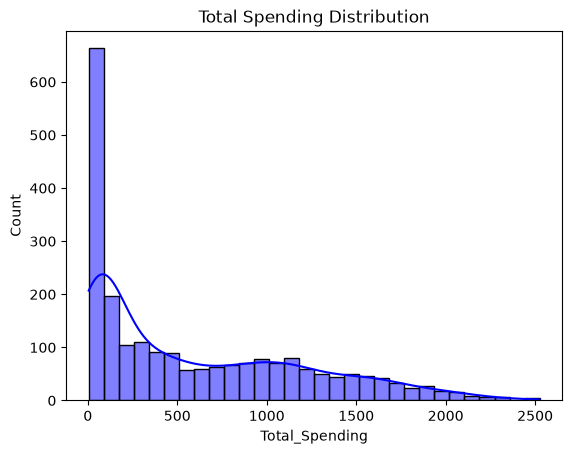

In [167]:
sns.histplot(df["Total_Spending"], bins=30, kde=True, color="blue")
plt.title("Total Spending Distribution")

Text(0.5, 1.0, 'Income by Education Level')

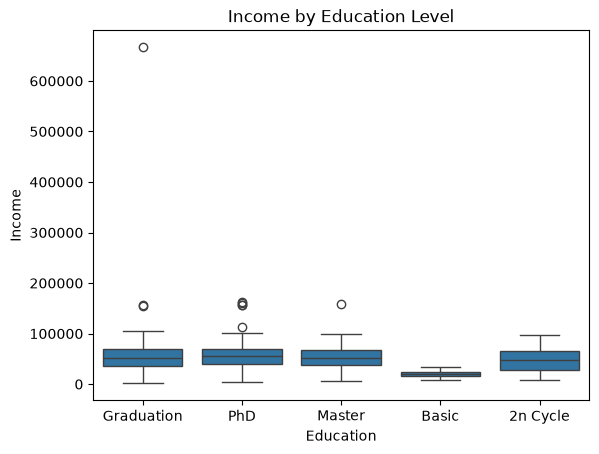

In [168]:
sns.boxplot(x="Education", y="Income", data=df)
plt.title("Income by Education Level")

Text(0.5, 1.0, 'Spending by Marital Status')

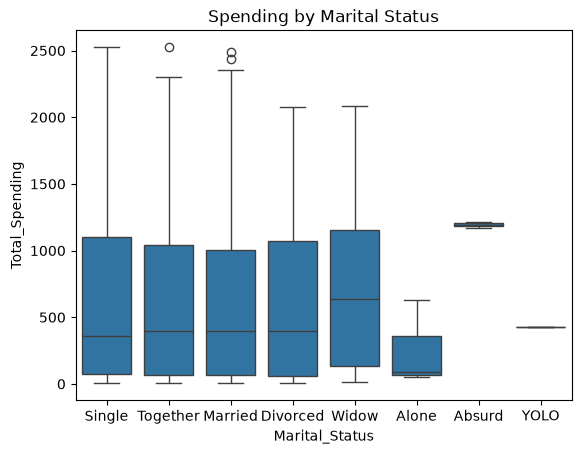

In [169]:
sns.boxplot(x= "Marital_Status", y="Total_Spending", data=df)
plt.title("Spending by Marital Status")

Text(0.5, 1.0, 'Correlation Matrix')

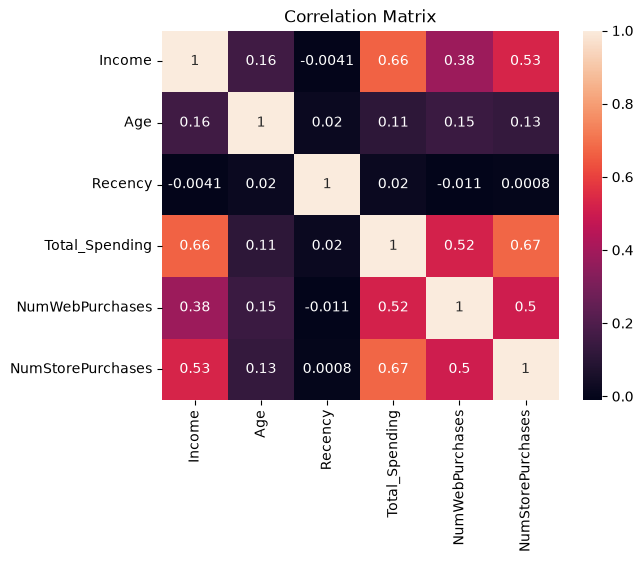

In [170]:
correlation = df[["Income", "Age", "Recency", "Total_Spending", "NumWebPurchases", "NumStorePurchases"]].corr()
sns.heatmap(correlation, annot=True, cmap="rocket")
plt.title("Correlation Matrix")

In [171]:
pivot_income = df.pivot_table(values="Income", index="Education", columns="Marital_Status", aggfunc="mean")
pivot_income

Marital_Status,Absurd,Alone,Divorced,Married,Single,Together,Widow,YOLO
Education,,,,,,,,
2n Cycle,NaN,NaN,49395.130435,46265.055556,53611.986486,44852.991228,51392.200000,NaN
Basic,NaN,NaN,9548.000000,21960.500000,18238.666667,21240.071429,22123.000000,NaN
Graduation,79244.0,34176.0,54526.042017,50805.628176,51323.595238,55743.176573,54976.657143,NaN
Master,65487.0,61331.0,50331.945946,53286.028986,53530.560000,52081.556604,57816.541667,NaN
PhD,NaN,35860.0,53096.615385,58067.651042,53275.163265,56001.594017,60288.083333,48432.0


Text(0.5, 1.0, 'Average Income by Education & Marital Status')

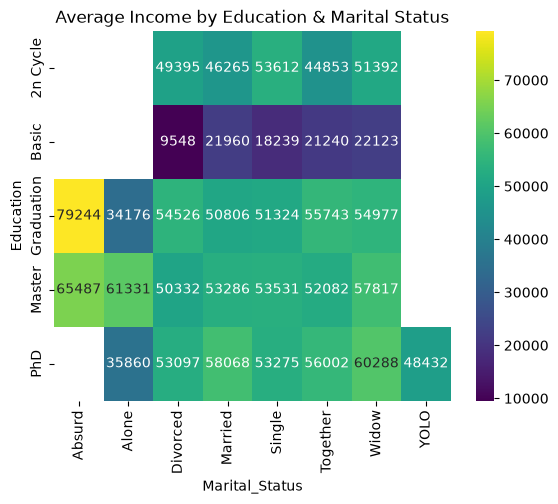

In [172]:
sns.heatmap(pivot_income, annot=True, fmt=".0f", cmap="viridis")
plt.title("Average Income by Education & Marital Status")

In [173]:
group1 = df.groupby("Education")["Total_Spending"].mean().sort_values(ascending=False)
group1

Education
PhD           672.409465
Graduation    619.898846
Master        611.781081
2n Cycle      496.527094
Basic          81.796296
Name: Total_Spending, dtype: float64

Text(0, 0.5, 'Average Total Spending')

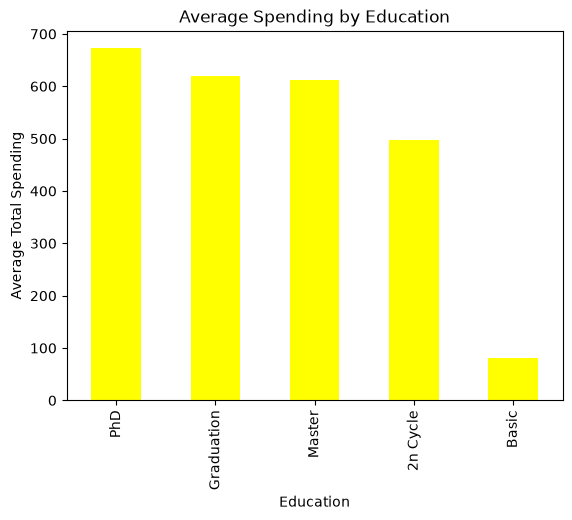

In [174]:
group1.plot(kind="bar", color="yellow")
plt.title("Average Spending by Education")
plt.ylabel("Average Total Spending")

In [175]:
df["AcceptedAny"] = df[["AcceptedCmp1", "AcceptedCmp2", "AcceptedCmp3", "AcceptedCmp4", "AcceptedCmp5", "Response"]].sum(axis=1)

In [176]:
df["AcceptedAny"].unique()

array([1, 0, 3, 2, 4, 5])

In [177]:
df["AcceptedAny"] = df["AcceptedAny"].apply(lambda x: 1 if x > 0 else 0)

In [178]:
df["AcceptedAny"].unique()

array([1, 0])

In [179]:
group2 = df.groupby("Marital_Status")["AcceptedAny"].mean().sort_values(ascending=False)
group2

Marital_Status
Absurd      0.500000
YOLO        0.500000
Widow       0.350649
Alone       0.333333
Single      0.308333
Divorced    0.297414
Married     0.251157
Together    0.250000
Name: AcceptedAny, dtype: float64

Text(0, 0.5, 'Acceptance Rate')

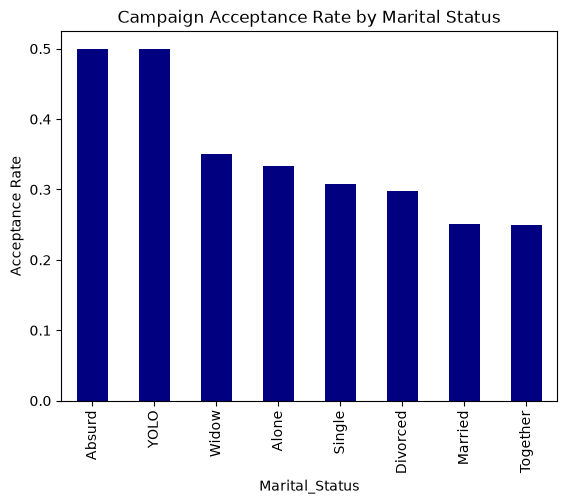

In [180]:
group2.plot(kind="bar", color="navy")
plt.title("Campaign Acceptance Rate by Marital Status")
plt.ylabel("Acceptance Rate")

In [181]:
bins = [18, 30, 40, 50, 60, 70, 90]
labels = ["18-29", "30-39", "40-49", "50-59", "60-69", "70+"]
df["AgeGroup"] = pd.cut(df["Age"], bins=bins, labels=labels)

In [182]:
group3 = df.groupby("AgeGroup")["Income"].mean()

Text(0.5, 0, 'Average Income')

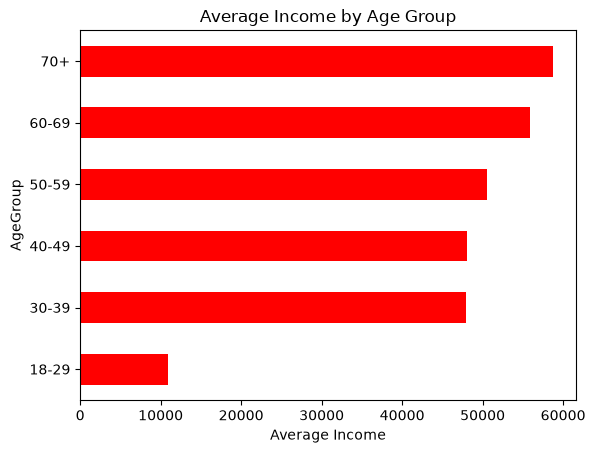

In [183]:
group3.plot(kind="barh", color="red")
plt.title("Average Income by Age Group")
plt.xlabel("Average Income")

In [184]:
df.to_csv("../data/analysed_data.csv", index=False)